<a href="https://colab.research.google.com/github/pratixa5548/using-decision-tree-to-predict-diabetes-readmission-probability/blob/main/diabetes_readmission_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# 0. INSTALL REQUIRED PACKAGES
# ============================================================

!pip install -q imbalanced-learn scikit-learn seaborn

In [2]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import io
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from google.colab import files

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_recall_curve,
    roc_curve,
    auc
)

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

sns.set_theme(style='whitegrid')

RANDOM_STATE = 42

In [3]:
# ============================================================
# 2. UPLOAD DATASET
# ============================================================

uploaded = files.upload()

df = pd.read_csv(
    io.BytesIO(uploaded['diabetic_data.csv'])
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Saving diabetic_data.csv to diabetic_data.csv
Dataset loaded successfully.
Shape: (101766, 50)


In [4]:
# ============================================================
# 3. INITIAL DATA INSPECTION
# ============================================================

print("First 10 rows:")
display(df.head(10))

print("\nDataset shape:")
print(df.shape)

print("\nData types:")
display(df.dtypes)

print("\nColumn names:")
print(df.columns.tolist())

First 10 rows:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,?,?,31,6,16,0,0,0,414,411,250,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,[60-70),?,3,1,2,4,?,?,70,1,21,0,0,0,414,411,V45,7,NaN,NaN,Steady,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,[70-80),?,1,1,7,5,?,?,73,0,12,0,0,0,428,492,250,8,NaN,NaN,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,13,?,?,68,2,28,0,0,0,398,427,38,8,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,12,?,InternalMedicine,33,3,18,0,0,0,434,198,486,8,NaN,NaN,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO



Dataset shape:
(101766, 50)

Data types:


,0
encounter_id,int64
patient_nbr,int64
race,object
gender,object
age,object
weight,object
admission_type_id,int64
discharge_disposition_id,int64
admission_source_id,int64
time_in_hospital,int64



Column names:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [5]:
# ============================================================
# 4. CHECK UNKNOWN / MISSING VALUES
# ============================================================

print("Unknown values represented by '?'")

for col in df.columns:
    if df[col].dtype == object:
        count = (df[col] == '?').sum()
        if count > 0:
            print(f"{col}: {count}")

print(
    "\nUnknown/Invalid gender:",
    (df['gender'] == 'Unknown/Invalid').sum()
)

Unknown values represented by '?'
race: 2273
weight: 98569
payer_code: 40256
medical_specialty: 49949
diag_1: 21
diag_2: 358
diag_3: 1423

Unknown/Invalid gender: 3


In [6]:
# ============================================================
# 5. REMOVE HIGH-MISSINGNESS / UNUSED FEATURES
# ============================================================

df = df.drop(
    ['weight', 'payer_code', 'medical_specialty'],
    axis=1
)

print("Shape after dropping sparse columns:")
print(df.shape)

Shape after dropping sparse columns:
(101766, 47)


In [7]:
# ============================================================
# 6. REMOVE INVALID / UNSUITABLE ENCOUNTERS
# ============================================================

drop_idx = set()

# Missing primary/secondary/tertiary diagnosis
drop_idx.update(
    df[df['diag_1'] == '?'].index
)

drop_idx.update(
    df[df['diag_2'] == '?'].index
)

drop_idx.update(
    df[df['diag_3'] == '?'].index
)

# Missing race
drop_idx.update(
    df[df['race'] == '?'].index
)

# Unknown gender
drop_idx.update(
    df[df['gender'] == 'Unknown/Invalid'].index
)

# Discharge disposition 11 = expired
drop_idx.update(
    df[df['discharge_disposition_id'] == 11].index
)

df = df.drop(index=list(drop_idx))

print("Rows removed:", len(drop_idx))
print("New shape:", df.shape)

Rows removed: 5320
New shape: (96446, 47)


In [8]:
# ============================================================
# 7. REMOVE UNUSED MEDICATION FEATURES
# ============================================================

unused_medication_columns = [
    'citoglipton',
    'examide',
    'acetohexamide',
    'glimepiride-pioglitazone',
    'metformin-rosiglitazone'
]

df = df.drop(
    unused_medication_columns,
    axis=1,
    errors='ignore'
)

print("Shape:", df.shape)

Shape: (96446, 42)


In [9]:
# ============================================================
# 8. VERIFY UNKNOWN VALUES AFTER CLEANING
# ============================================================

for col in df.columns:
    if df[col].dtype == object:
        count = (df[col] == '?').sum()
        if count > 0:
            print(f"{col}: {count}")

print(
    "Unknown/Invalid gender:",
    (df['gender'] == 'Unknown/Invalid').sum()
)

Unknown/Invalid gender: 0


In [10]:
# ============================================================
# 9. CREATE SERVICE UTILIZATION FEATURE
# ============================================================

df['service_utilization'] = (
    df['number_outpatient']
    + df['number_emergency']
    + df['number_inpatient']
)

print(df['service_utilization'].describe())

count    96446.000000
mean         1.223628
std          2.315789
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max         80.000000
Name: service_utilization, dtype: float64


In [11]:
# ============================================================
# 10. CREATE NUMBER OF MEDICATION CHANGES
# ============================================================

medication_columns = [
    'metformin',
    'repaglinide',
    'nateglinide',
    'chlorpropamide',
    'glimepiride',
    'glipizide',
    'glyburide',
    'pioglitazone',
    'rosiglitazone',
    'acarbose',
    'miglitol',
    'insulin',
    'glyburide-metformin',
    'tolazamide',
    'metformin-pioglitazone',
    'glipizide-metformin',
    'troglitazone',
    'tolbutamide'
]

for col in medication_columns:

    temp_col = col + '_temp'

    df[temp_col] = df[col].apply(
        lambda x: 0 if x in ['No', 'Steady'] else 1
    )

df['numchange'] = 0

for col in medication_columns:

    temp_col = col + '_temp'

    df['numchange'] += df[temp_col]

    df.drop(temp_col, axis=1, inplace=True)

print(df['numchange'].value_counts())

numchange
0    70142
1    24922
2     1271
3      106
4        5
Name: count, dtype: int64


In [12]:
# ============================================================
# 11. RE-ENCODE ADMISSION TYPE
# ============================================================

df['admission_type_id'] = df['admission_type_id'].replace({
    2: 1,
    7: 1,
    6: 5,
    8: 5
})

print(df['admission_type_id'].value_counts())

admission_type_id
1    68414
3    18070
5     9952
4       10
Name: count, dtype: int64


In [13]:
# ============================================================
# 12. RE-ENCODE DISCHARGE DISPOSITION
# ============================================================

df['discharge_disposition_id'] = df[
    'discharge_disposition_id'
].replace({

    6: 1,
    8: 1,
    9: 1,
    13: 1,

    3: 2,
    4: 2,
    5: 2,
    14: 2,
    22: 2,
    23: 2,
    24: 2,

    12: 10,
    15: 10,
    16: 10,
    17: 10,

    25: 18,
    26: 18
})

print(df['discharge_disposition_id'].value_counts())

discharge_disposition_id
1     70758
2     20282
18     4565
7       592
28      137
10       97
19        8
27        5
20        2
Name: count, dtype: int64


In [14]:
# ============================================================
# 13. RE-ENCODE ADMISSION SOURCE
# ============================================================

df['admission_source_id'] = df[
    'admission_source_id'
].replace({

    2: 1,
    3: 1,

    5: 4,
    6: 4,
    10: 4,
    22: 4,
    25: 4,

    15: 9,
    17: 9,
    20: 9,
    21: 9,

    13: 11,
    14: 11
})

print(df['admission_source_id'].value_counts())

admission_source_id
7     54847
1     29308
9      6676
4      5596
8        14
11        5
Name: count, dtype: int64


In [15]:
# ============================================================
# 14. ENCODE BINARY VARIABLES
# ============================================================

df['change'] = df['change'].map({
    'Ch': 1,
    'No': 0
})

df['gender'] = df['gender'].map({
    'Male': 1,
    'Female': 0
})

df['diabetesMed'] = df['diabetesMed'].map({
    'Yes': 1,
    'No': 0
})

In [16]:
# ============================================================
# 15. ENCODE MEDICATION FEATURES
# ============================================================

for col in medication_columns:

    df[col] = df[col].replace({
        'No': 0,
        'Steady': 1,
        'Up': 1,
        'Down': 1
    })

In [17]:
# ============================================================
# 16. ENCODE HbA1c RESULT
# ============================================================

df['A1Cresult'] = df['A1Cresult'].replace({
    '>7': 1,
    '>8': 1,
    'Norm': 0,
    'None': -99
})

In [18]:
# ============================================================
# 17. ENCODE GLUCOSE RESULT
# ============================================================

df['max_glu_serum'] = df['max_glu_serum'].replace({
    '>200': 1,
    '>300': 1,
    'Norm': 0,
    'None': -99
})

In [19]:
# ============================================================
# 18. ENCODE AGE GROUP
# ============================================================

age_mapping = {
    '[0-10)': 1,
    '[10-20)': 2,
    '[20-30)': 3,
    '[30-40)': 4,
    '[40-50)': 5,
    '[50-60)': 6,
    '[60-70)': 7,
    '[70-80)': 8,
    '[80-90)': 9,
    '[90-100)': 10
}

df['age'] = df['age'].map(age_mapping)

print(df['age'].value_counts().sort_index())

age
1        64
2       466
3      1471
4      3538
5      9208
6     16546
7     21521
8     24815
9     16223
10     2594
Name: count, dtype: int64


In [20]:
# ============================================================
# 19. CREATE BINARY READMISSION TARGET
# ============================================================

df['readmitted'] = df['readmitted'].replace({
    '<30': 1,
    '>30': 0,
    'NO': 0
})

print(df['readmitted'].value_counts())

readmitted
0    85380
1    11066
Name: count, dtype: int64


In [21]:
# ============================================================
# 20. CHECK TARGET
# ============================================================

print("Unique target values:")
print(df['readmitted'].unique())

print("\nTarget distribution:")
print(df['readmitted'].value_counts())

Unique target values:
[0 1]

Target distribution:
readmitted
0    85380
1    11066
Name: count, dtype: int64


In [22]:
# ============================================================
# 21. CREATE DIAGNOSIS FEATURES
# ============================================================

for diag in ['diag_1', 'diag_2', 'diag_3']:

    df[f'level1_{diag}'] = df[diag]
    df[f'level2_{diag}'] = df[diag]

In [23]:
# ============================================================
# 22. HANDLE V AND E DIAGNOSIS CODES
# ============================================================

for diag in ['diag_1', 'diag_2', 'diag_3']:

    df.loc[
        df[diag].str.contains('V', na=False),
        [f'level1_{diag}', f'level2_{diag}']
    ] = 0

    df.loc[
        df[diag].str.contains('E', na=False),
        [f'level1_{diag}', f'level2_{diag}']
    ] = 0

In [24]:
# ============================================================
# 23. CONVERT DIAGNOSIS VALUES TO NUMERIC
# ============================================================

for diag in ['diag_1', 'diag_2', 'diag_3']:

    for level in ['level1', 'level2']:

        col = f'{level}_{diag}'

        df[col] = df[col].replace('?', -1)

        df[col] = pd.to_numeric(
            df[col],
            errors='coerce'
        )

In [25]:
# ============================================================
# 24. CREATE LEVEL-1 DIAGNOSIS CATEGORIES
# ============================================================

def diagnosis_level1(x):

    if pd.isna(x):
        return 0

    x = float(x)

    if 390 <= x < 460 or np.floor(x) == 785:
        return 1

    elif 460 <= x < 520 or np.floor(x) == 786:
        return 2

    elif 520 <= x < 580 or np.floor(x) == 787:
        return 3

    elif np.floor(x) == 250:
        return 4

    elif 800 <= x < 1000:
        return 5

    elif 710 <= x < 740:
        return 6

    elif 580 <= x < 630 or np.floor(x) == 788:
        return 7

    elif 140 <= x < 240:
        return 8

    else:
        return 0


for diag in ['diag_1', 'diag_2', 'diag_3']:

    df[f'level1_{diag}'] = df[
        f'level1_{diag}'
    ].apply(diagnosis_level1)

In [26]:
# ============================================================
# 25. CREATE LEVEL-2 DIAGNOSIS CATEGORIES
# ============================================================

def diagnosis_level2(x):

    if pd.isna(x):
        return 0

    x = float(x)

    if 390 <= x < 399:
        return 1
    elif 401 <= x < 415:
        return 2
    elif 415 <= x < 460:
        return 3
    elif np.floor(x) == 785:
        return 4
    elif 460 <= x < 489:
        return 5
    elif 490 <= x < 497:
        return 6
    elif 500 <= x < 520:
        return 7
    elif np.floor(x) == 786:
        return 8
    elif 520 <= x < 530:
        return 9
    elif 530 <= x < 544:
        return 10
    elif 550 <= x < 554:
        return 11
    elif 555 <= x < 580:
        return 12
    elif np.floor(x) == 787:
        return 13
    elif np.floor(x) == 250:
        return 14
    elif 800 <= x < 1000:
        return 15
    elif 710 <= x < 740:
        return 16
    elif 580 <= x < 630:
        return 17
    elif np.floor(x) == 788:
        return 18
    elif 140 <= x < 240:
        return 19
    elif 240 <= x < 280 and np.floor(x) != 250:
        return 20
    elif 680 <= x < 710 or np.floor(x) == 782:
        return 21
    elif 290 <= x < 320:
        return 22
    else:
        return 0


for diag in ['diag_1', 'diag_2', 'diag_3']:

    df[f'level2_{diag}'] = df[
        f'level2_{diag}'
    ].apply(diagnosis_level2)

In [27]:
# ============================================================
# 26. CHECK DIAGNOSIS FEATURES
# ============================================================

diagnosis_features = [
    'level1_diag_1',
    'level1_diag_2',
    'level1_diag_3',
    'level2_diag_1',
    'level2_diag_2',
    'level2_diag_3'
]

display(
    df[diagnosis_features].head()
)

,level1_diag_1,level1_diag_2,level1_diag_3,level2_diag_1,level2_diag_2,level2_diag_3
1,0,4,0,20,14,20
2,0,4,0,0,14,0
3,0,4,1,0,14,2
4,8,8,4,19,19,14
5,1,1,4,2,2,14


In [28]:
# ============================================================
# 27. KEEP ONE ENCOUNTER PER PATIENT
# ============================================================

df = df.drop_duplicates(
    subset=['patient_nbr'],
    keep='first'
).copy()

print("Shape after keeping first encounter per patient:")
print(df.shape)

Shape after keeping first encounter per patient:
(67580, 50)


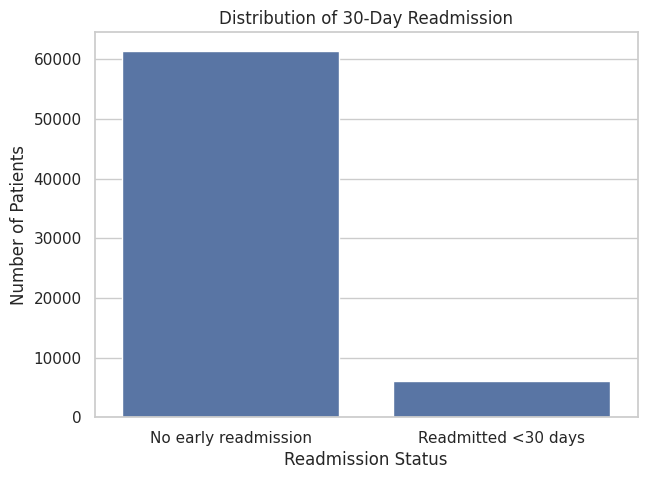

In [29]:
# ============================================================
# 28. READMISSION DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    x='readmitted',
    data=df
)

plt.xticks(
    [0, 1],
    ['No early readmission', 'Readmitted <30 days']
)

plt.xlabel('Readmission Status')
plt.ylabel('Number of Patients')
plt.title('Distribution of 30-Day Readmission')

plt.show()

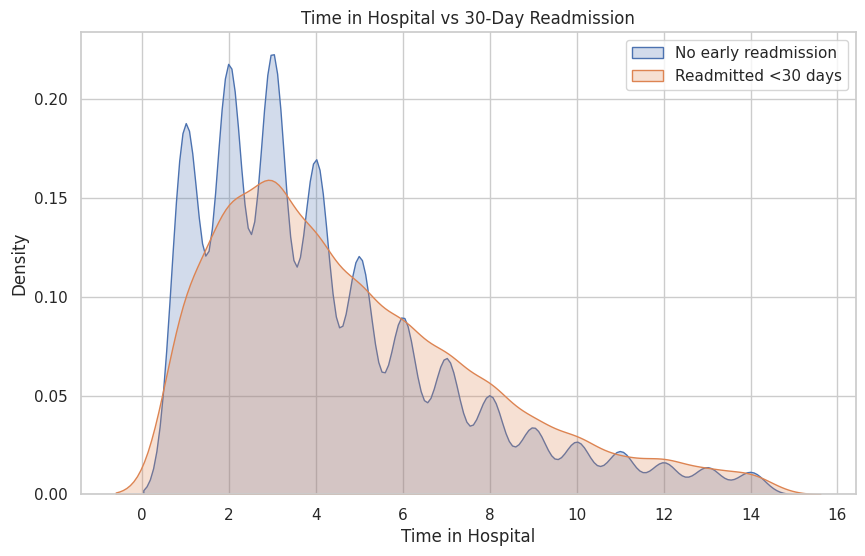

In [30]:
# ============================================================
# 29. TIME IN HOSPITAL VS READMISSION
# ============================================================

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df[df['readmitted'] == 0],
    x='time_in_hospital',
    fill=True,
    label='No early readmission'
)

sns.kdeplot(
    data=df[df['readmitted'] == 1],
    x='time_in_hospital',
    fill=True,
    label='Readmitted <30 days'
)

plt.xlabel('Time in Hospital')
plt.ylabel('Density')
plt.title('Time in Hospital vs 30-Day Readmission')
plt.legend()

plt.show()

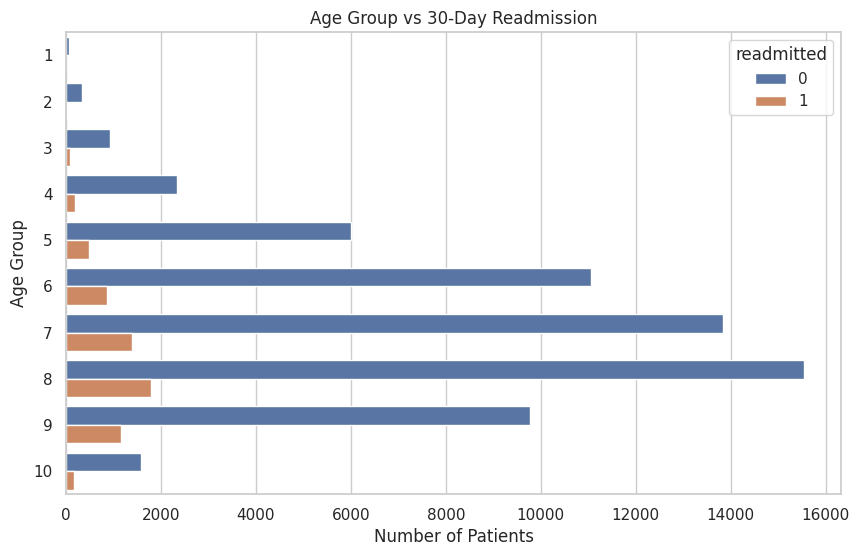

In [31]:
# ============================================================
# 30. AGE VS READMISSION
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    y='age',
    hue='readmitted',
    data=df
)

plt.xlabel('Number of Patients')
plt.ylabel('Age Group')
plt.title('Age Group vs 30-Day Readmission')

plt.show()

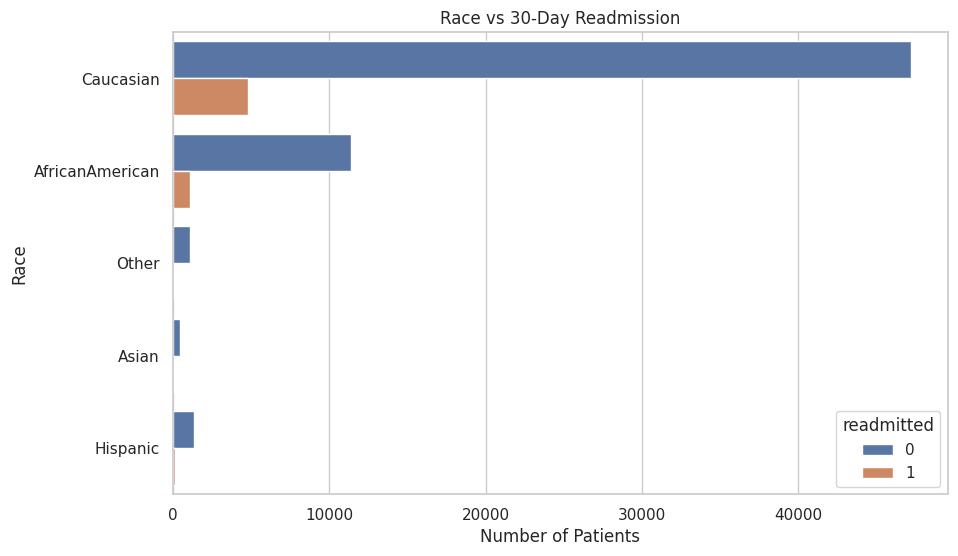

In [32]:
# ============================================================
# 31. RACE VS READMISSION
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    y='race',
    hue='readmitted',
    data=df
)

plt.xlabel('Number of Patients')
plt.ylabel('Race')
plt.title('Race vs 30-Day Readmission')

plt.show()

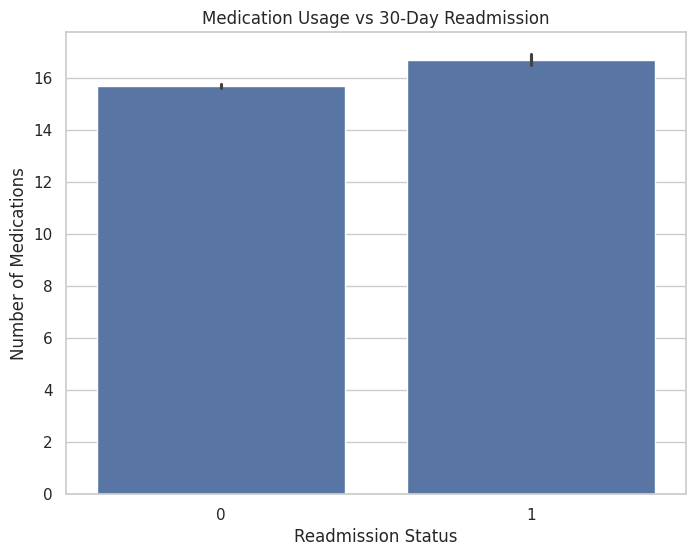

In [33]:
# ============================================================
# 32. NUMBER OF MEDICATIONS VS READMISSION
# ============================================================

plt.figure(figsize=(8, 6))

sns.barplot(
    x='readmitted',
    y='num_medications',
    data=df
)

plt.xlabel('Readmission Status')
plt.ylabel('Number of Medications')
plt.title('Medication Usage vs 30-Day Readmission')

plt.show()

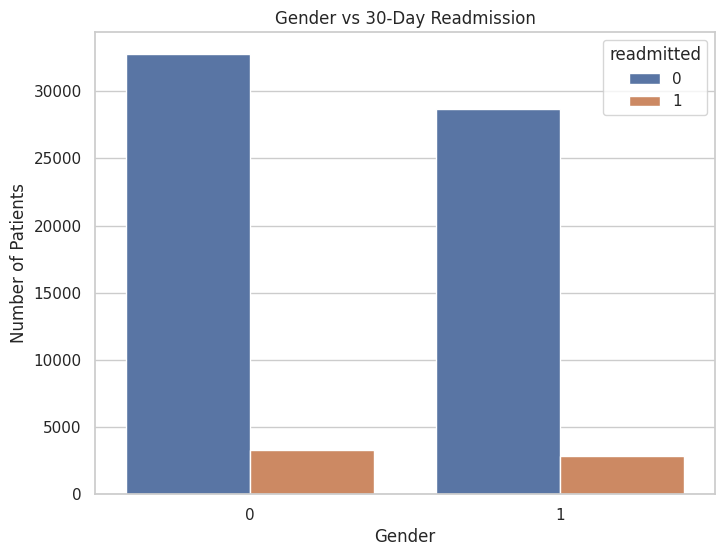

In [34]:
# ============================================================
# 33. GENDER VS READMISSION
# ============================================================

plt.figure(figsize=(8, 6))

sns.countplot(
    x='gender',
    hue='readmitted',
    data=df
)

plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.title('Gender vs 30-Day Readmission')

plt.show()

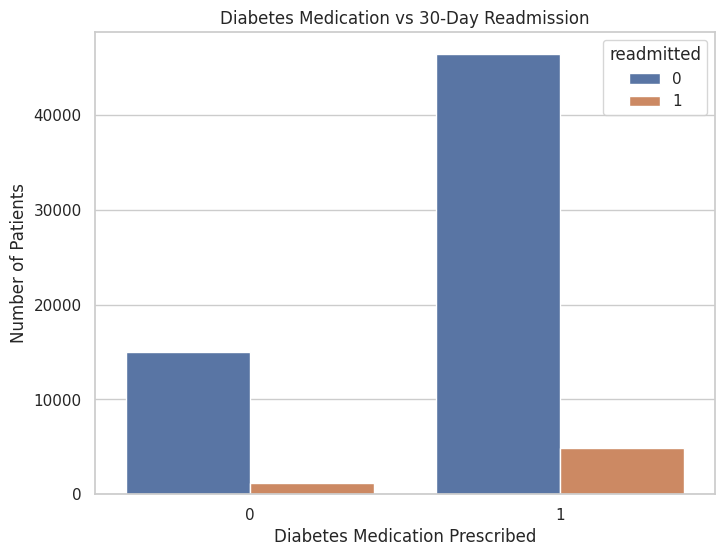

In [35]:
# ============================================================
# 34. DIABETES MEDICATION VS READMISSION
# ============================================================

plt.figure(figsize=(8, 6))

sns.countplot(
    x='diabetesMed',
    hue='readmitted',
    data=df
)

plt.xlabel('Diabetes Medication Prescribed')
plt.ylabel('Number of Patients')
plt.title('Diabetes Medication vs 30-Day Readmission')

plt.show()

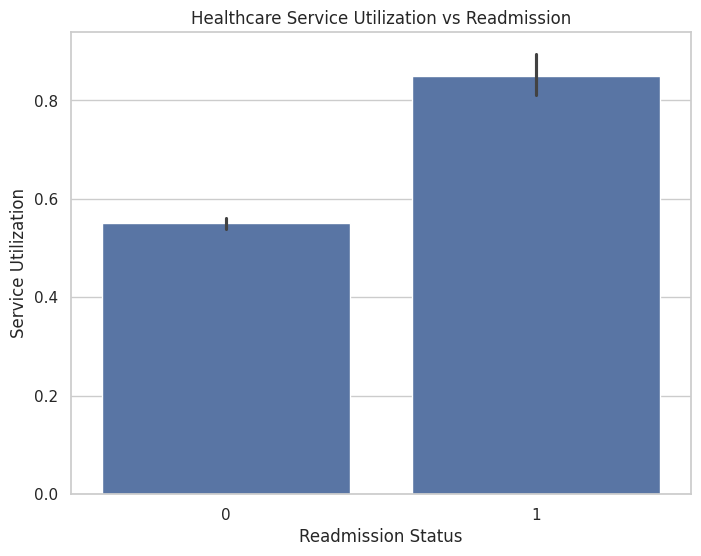

In [36]:
# ============================================================
# 35. SERVICE UTILIZATION VS READMISSION
# ============================================================

plt.figure(figsize=(8, 6))

sns.barplot(
    x='readmitted',
    y='service_utilization',
    data=df
)

plt.xlabel('Readmission Status')
plt.ylabel('Service Utilization')
plt.title('Healthcare Service Utilization vs Readmission')

plt.show()

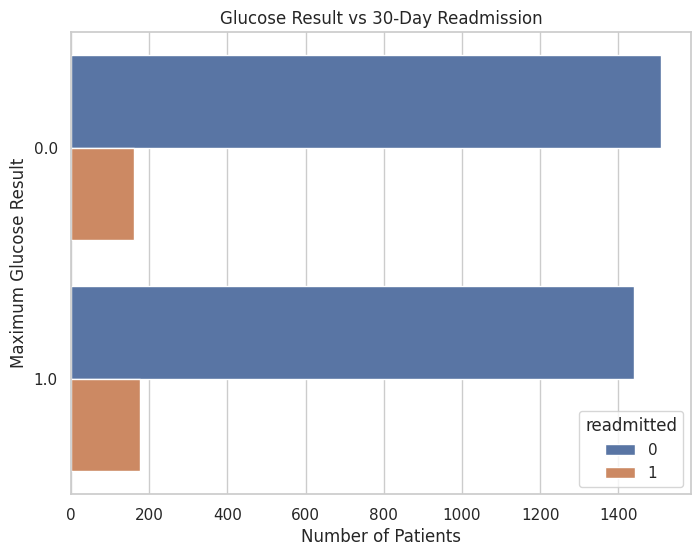

In [37]:
# ============================================================
# 36. GLUCOSE RESULT VS READMISSION
# ============================================================

plt.figure(figsize=(8, 6))

sns.countplot(
    y='max_glu_serum',
    hue='readmitted',
    data=df
)

plt.xlabel('Number of Patients')
plt.ylabel('Maximum Glucose Result')
plt.title('Glucose Result vs 30-Day Readmission')

plt.show()

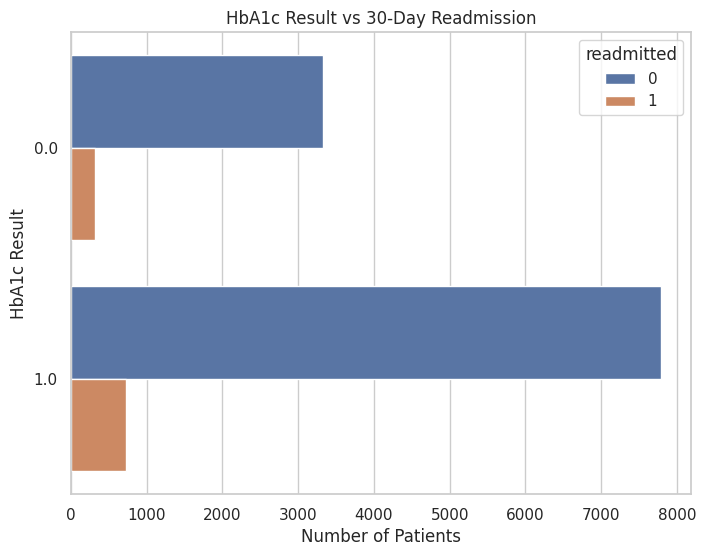

In [38]:
# ============================================================
# 37. HbA1c VS READMISSION
# ============================================================

plt.figure(figsize=(8, 6))

sns.countplot(
    y='A1Cresult',
    hue='readmitted',
    data=df
)

plt.xlabel('Number of Patients')
plt.ylabel('HbA1c Result')
plt.title('HbA1c Result vs 30-Day Readmission')

plt.show()

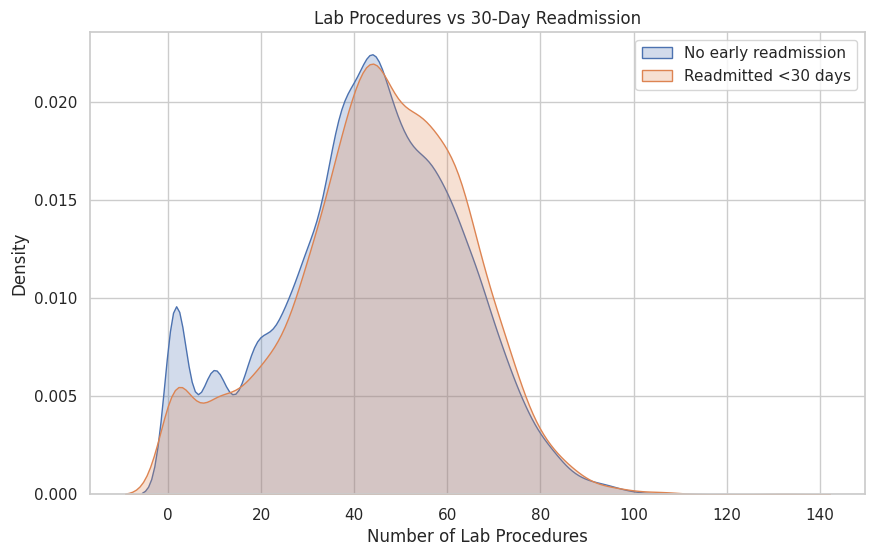

In [39]:
# ============================================================
# 38. LAB PROCEDURES VS READMISSION
# ============================================================

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df[df['readmitted'] == 0],
    x='num_lab_procedures',
    fill=True,
    label='No early readmission'
)

sns.kdeplot(
    data=df[df['readmitted'] == 1],
    x='num_lab_procedures',
    fill=True,
    label='Readmitted <30 days'
)

plt.xlabel('Number of Lab Procedures')
plt.ylabel('Density')
plt.title('Lab Procedures vs 30-Day Readmission')
plt.legend()

plt.show()

In [40]:
# ============================================================
# 39. CONVERT AGE GROUP TO APPROXIMATE MIDPOINT
# ============================================================

age_midpoints = {
    1: 5,
    2: 15,
    3: 25,
    4: 35,
    5: 45,
    6: 55,
    7: 65,
    8: 75,
    9: 85,
    10: 95
}

df['age'] = df['age'].map(age_midpoints)

print(df['age'].value_counts().sort_index())

age
5        63
15      357
25     1004
35     2519
45     6494
55    11903
65    15228
75    17331
85    10931
95     1750
Name: count, dtype: int64


In [41]:
# ============================================================
# 40. CREATE TOTAL MEDICATION COUNT
# ============================================================

df['nummed'] = 0

for col in medication_columns:
    df['nummed'] += df[col]

print(df['nummed'].value_counts().sort_index())

nummed
0    16267
1    29976
2    14864
3     5444
4      976
5       49
6        4
Name: count, dtype: int64


In [42]:
# ============================================================
# 41. LOG TRANSFORM SKEWED UTILIZATION VARIABLES
# ============================================================

log_columns = [
    'number_outpatient',
    'number_emergency',
    'number_inpatient'
]

for col in log_columns:

    df[col + '_log1p'] = np.log1p(
        df[col].clip(lower=0)
    )

print(
    df[
        [col + '_log1p' for col in log_columns]
    ].describe()
)

       number_outpatient_log1p  number_emergency_log1p  number_inpatient_log1p
count             67580.000000            67580.000000            67580.000000
mean                  0.137005                0.062194                0.105529
std                   0.384090                0.232136                0.301657
min                   0.000000                0.000000                0.000000
25%                   0.000000                0.000000                0.000000
50%                   0.000000                0.000000                0.000000
75%                   0.000000                0.000000                0.000000
max                   3.761200                3.761200                2.564949


In [43]:
# ============================================================
# 42. REMOVE ORIGINAL UTILIZATION FEATURES
# ============================================================

df = df.drop(
    [
        'number_outpatient',
        'number_inpatient',
        'number_emergency',
        'service_utilization'
    ],
    axis=1
)

print(df.shape)

(67580, 50)


In [44]:
# ============================================================
# 43. CREATE INTERACTION FEATURES
# ============================================================

interaction_terms = [
    ('num_medications', 'time_in_hospital'),
    ('num_medications', 'num_procedures'),
    ('time_in_hospital', 'num_lab_procedures'),
    ('num_medications', 'num_lab_procedures'),
    ('num_medications', 'number_diagnoses'),
    ('age', 'number_diagnoses'),
    ('change', 'num_medications'),
    ('number_diagnoses', 'time_in_hospital'),
    ('num_medications', 'numchange')
]

for feature_a, feature_b in interaction_terms:

    name = feature_a + '|' + feature_b

    df[name] = (
        df[feature_a] *
        df[feature_b]
    )

print("Interaction features created.")

Interaction features created.


In [45]:
# ============================================================
# 44. REMOVE RAW DIAGNOSIS CODES
# ============================================================

df = df.drop(
    [
        'diag_1',
        'diag_2',
        'diag_3',
        'level2_diag_1',
        'level1_diag_2',
        'level2_diag_2',
        'level1_diag_3',
        'level2_diag_3'
    ],
    axis=1,
    errors='ignore'
)

print(df.shape)

(67580, 51)


In [46]:
# ============================================================
# 45. PREPARE CATEGORICAL VARIABLES
# ============================================================

categorical_columns = [
    'race',
    'gender',
    'admission_type_id',
    'discharge_disposition_id',
    'admission_source_id',
    'max_glu_serum',
    'A1Cresult',
    'level1_diag_1'
]

categorical_columns = [
    col for col in categorical_columns
    if col in df.columns
]

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['race', 'gender', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'max_glu_serum', 'A1Cresult', 'level1_diag_1']


In [47]:
# ============================================================
# 46. ONE-HOT ENCODE CATEGORICAL VARIABLES
# ============================================================

df_model = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print("Shape after one-hot encoding:")
print(df_model.shape)

Shape after one-hot encoding:
(67580, 74)


In [48]:
# ============================================================
# 47. CHECK MISSING VALUES
# ============================================================

missing_values = (
    df_model.isnull()
    .sum()
    .sort_values(ascending=False)
)

print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [49]:
# ============================================================
# 48. CHECK REMAINING MISSING VALUES
# ============================================================

print("Missing values before train-test split:")

missing_values = df_model.isnull().sum()

missing_values = missing_values[
    missing_values > 0
].sort_values(ascending=False)

display(missing_values)

print(
    "\nTotal missing values:",
    df_model.isnull().sum().sum()
)

Missing values before train-test split:


,0



Total missing values: 0


In [50]:
# ============================================================
# 49. REMOVE IDENTIFIER COLUMNS
# ============================================================

identifier_columns = [
    'encounter_id',
    'patient_nbr'
]

df_model = df_model.drop(
    identifier_columns,
    axis=1,
    errors='ignore'
)

print(df_model.shape)

(67580, 72)


In [51]:
# ============================================================
# 50. DEFINE FEATURES AND TARGET
# ============================================================

X = df_model.drop(
    'readmitted',
    axis=1
)

y = df_model['readmitted'].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (67580, 71)
y shape: (67580,)

Target distribution:
readmitted
0    61451
1     6129
Name: count, dtype: int64


In [52]:
# ============================================================
# 51. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training set: (54064, 71)
Testing set: (13516, 71)

Training target:
readmitted
0    49161
1     4903
Name: count, dtype: int64

Testing target:
readmitted
0    12290
1     1226
Name: count, dtype: int64


In [53]:
# ============================================================
# 52. HANDLE MISSING VALUES USING TRAINING DATA ONLY
# ============================================================

# Identify numerical columns
numeric_columns = X_train.select_dtypes(
    include=np.number
).columns

# Calculate medians ONLY from training data
train_medians = X_train[numeric_columns].median()

# Apply training-derived medians to training data
X_train = X_train.copy()

X_train[numeric_columns] = X_train[numeric_columns].fillna(
    train_medians
)

# Apply the SAME training medians to test data
X_test = X_test.copy()

X_test[numeric_columns] = X_test[numeric_columns].fillna(
    train_medians
)

print(
    "Missing values in training data:",
    X_train.isnull().sum().sum()
)

print(
    "Missing values in test data:",
    X_test.isnull().sum().sum()
)

Missing values in training data: 0
Missing values in test data: 0


In [54]:
# ============================================================
# 53. APPLY SMOTE TO TRAINING DATA ONLY
# ============================================================

print(
    "Before SMOTE:",
    Counter(y_train)
)

smote = SMOTE(
    random_state=RANDOM_STATE
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(
    "After SMOTE:",
    Counter(y_train_smote)
)

Before SMOTE: Counter({0: 49161, 1: 4903})
After SMOTE: Counter({0: 49161, 1: 49161})


In [55]:
# ============================================================
# 54. TRAIN DECISION TREE
# ============================================================

dtree = DecisionTreeClassifier(
    max_depth=28,
    criterion='entropy',
    min_samples_split=10,
    random_state=RANDOM_STATE
)

dtree.fit(
    X_train_smote,
    y_train_smote
)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [56]:
# ============================================================
# 55. DECISION TREE PREDICTIONS
# ============================================================

dtree_pred = dtree.predict(X_test)

dtree_prob = dtree.predict_proba(
    X_test
)[:, 1]

In [57]:
# ============================================================
# 56. DECISION TREE PERFORMANCE
# ============================================================

accuracy_dtree = accuracy_score(
    y_test,
    dtree_pred
)

precision_dtree = precision_score(
    y_test,
    dtree_pred,
    zero_division=0
)

recall_dtree = recall_score(
    y_test,
    dtree_pred,
    zero_division=0
)

f1_dtree = f1_score(
    y_test,
    dtree_pred,
    zero_division=0
)

roc_auc_dtree = roc_auc_score(
    y_test,
    dtree_prob
)

print("=" * 60)
print("DECISION TREE PERFORMANCE")
print("=" * 60)

print(f"Accuracy : {accuracy_dtree:.4f}")
print(f"Precision: {precision_dtree:.4f}")
print(f"Recall   : {recall_dtree:.4f}")
print(f"F1 Score : {f1_dtree:.4f}")
print(f"ROC-AUC  : {roc_auc_dtree:.4f}")

DECISION TREE PERFORMANCE
Accuracy : 0.8212
Precision: 0.1111
Recall   : 0.1387
F1 Score : 0.1234
ROC-AUC  : 0.5205


In [58]:
# ============================================================
# 57. DECISION TREE CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        dtree_pred,
        target_names=[
            'No early readmission',
            'Readmitted <30 days'
        ],
        zero_division=0
    )
)

                      precision    recall  f1-score   support

No early readmission       0.91      0.89      0.90     12290
 Readmitted <30 days       0.11      0.14      0.12      1226

            accuracy                           0.82     13516
           macro avg       0.51      0.51      0.51     13516
        weighted avg       0.84      0.82      0.83     13516



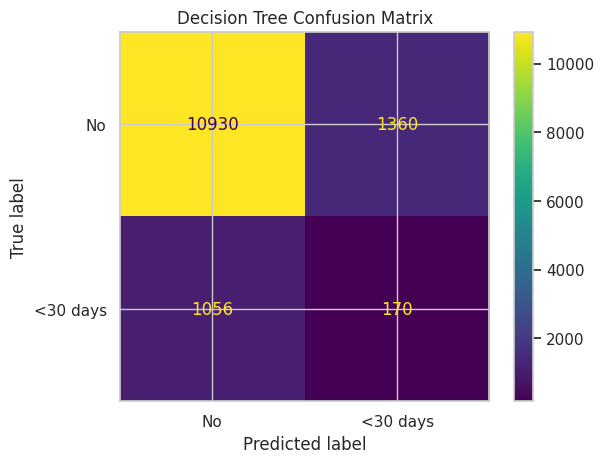

In [59]:
# ============================================================
# 58. DECISION TREE CONFUSION MATRIX
# ============================================================

cm_dtree = confusion_matrix(
    y_test,
    dtree_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dtree,
    display_labels=[
        'No',
        '<30 days'
    ]
)

disp.plot(
    values_format='d'
)

plt.title('Decision Tree Confusion Matrix')
plt.show()

In [60]:
# ============================================================
# 59. DECISION TREE FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dtree.feature_importances_
})

top_features = (
    feature_importance
    .sort_values(
        'Importance',
        ascending=False
    )
    .head(10)
)

print("Top 10 Decision Tree Features:")
display(top_features)

Top 10 Decision Tree Features:


,Feature,Importance
30,number_inpatient_log1p,0.204426
24,change,0.081522
34,num_medications|num_lab_procedures,0.038743
44,gender_1,0.032886
33,time_in_hospital|num_lab_procedures,0.031417
37,change|num_medications,0.028935
2,num_lab_procedures,0.028816
36,age|number_diagnoses,0.027995
0,age,0.027420
31,num_medications|time_in_hospital,0.026094


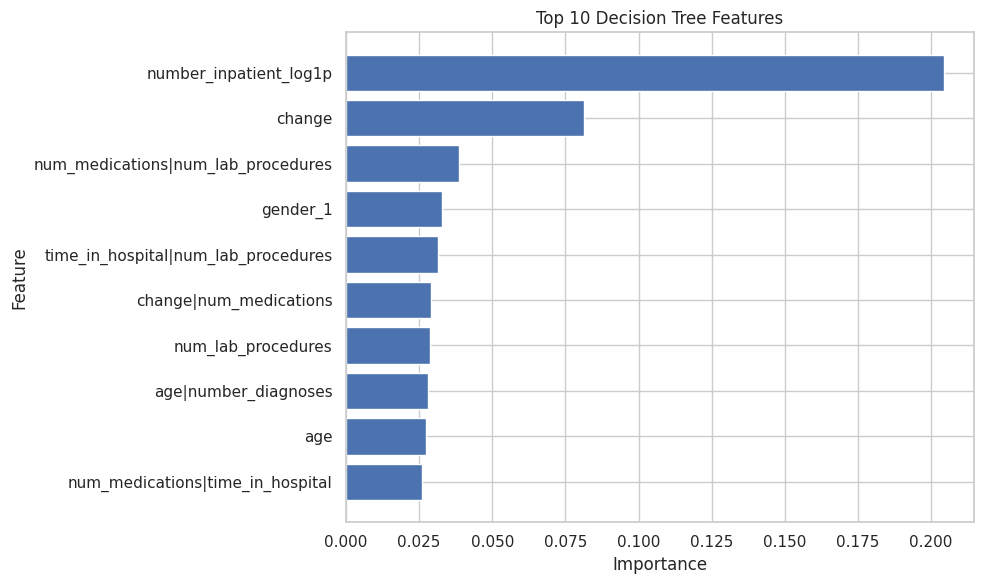

In [61]:
# ============================================================
# 60. PLOT FEATURE IMPORTANCE
# ============================================================

plot_features = top_features.sort_values(
    'Importance'
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_features['Feature'],
    plot_features['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Decision Tree Features')

plt.tight_layout()
plt.show()

In [62]:
# ============================================================
# 61. KNN PIPELINE SETUP
# ============================================================

from imblearn.pipeline import Pipeline as ImbPipeline

# Create a pipeline so that:
# 1. SMOTE is applied separately inside each CV training fold
# 2. Scaling is fitted separately inside each CV training fold
# 3. KNN is then trained on the processed fold

knn_pipeline = ImbPipeline(
    steps=[
        (
            'smote',
            SMOTE(
                random_state=RANDOM_STATE
            )
        ),
        (
            'scaler',
            StandardScaler()
        ),
        (
            'knn',
            KNeighborsClassifier(
                algorithm='brute',
                n_jobs=-1
            )
        )
    ]
)

print("KNN pipeline created successfully.")

KNN pipeline created successfully.


In [63]:
# ============================================================
# 62. KNN GRID SEARCH WITH LEAKAGE-SAFE PIPELINE
# ============================================================

param_grid = {
    'knn__n_neighbors': [3, 5],
    'knn__weights': ['uniform'],
    'knn__p': [2]
}

grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(
    X_train,
    y_train
)

print(
    "Best KNN parameters:",
    grid_search.best_params_
)

print(
    "Best cross-validation ROC-AUC:",
    grid_search.best_score_
)

Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best KNN parameters: {'knn__n_neighbors': 5, 'knn__p': 2, 'knn__weights': 'uniform'}
Best cross-validation ROC-AUC: 0.5392561490137752


In [64]:
# ============================================================
# 63. BEST KNN MODEL
# ============================================================

best_knn = grid_search.best_estimator_

# Predict directly using the original test data.
# The pipeline automatically applies the fitted preprocessing.

knn_pred = best_knn.predict(
    X_test
)

knn_prob = best_knn.predict_proba(
    X_test
)[:, 1]

print("KNN predictions generated successfully.")

KNN predictions generated successfully.


In [65]:
# ============================================================
# 64. KNN PERFORMANCE
# ============================================================

accuracy_knn = accuracy_score(
    y_test,
    knn_pred
)

precision_knn = precision_score(
    y_test,
    knn_pred,
    zero_division=0
)

recall_knn = recall_score(
    y_test,
    knn_pred,
    zero_division=0
)

f1_knn = f1_score(
    y_test,
    knn_pred,
    zero_division=0
)

roc_auc_knn = roc_auc_score(
    y_test,
    knn_prob
)

print("=" * 60)
print("KNN PERFORMANCE")
print("=" * 60)

print(f"Accuracy : {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall   : {recall_knn:.4f}")
print(f"F1 Score : {f1_knn:.4f}")
print(f"ROC-AUC  : {roc_auc_knn:.4f}")

KNN PERFORMANCE
Accuracy : 0.8273
Precision: 0.1226
Recall   : 0.1468
F1 Score : 0.1336
ROC-AUC  : 0.5481


In [66]:
# ============================================================
# 65. KNN CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        knn_pred,
        target_names=[
            'No early readmission',
            'Readmitted <30 days'
        ],
        zero_division=0
    )
)

                      precision    recall  f1-score   support

No early readmission       0.91      0.90      0.90     12290
 Readmitted <30 days       0.12      0.15      0.13      1226

            accuracy                           0.83     13516
           macro avg       0.52      0.52      0.52     13516
        weighted avg       0.84      0.83      0.83     13516



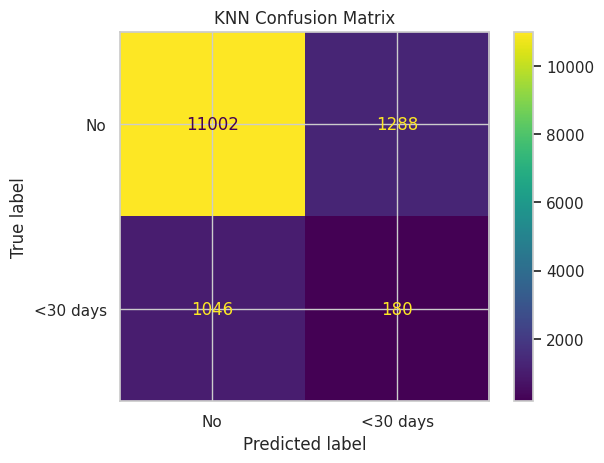

In [67]:
# ============================================================
# 66. KNN CONFUSION MATRIX
# ============================================================

cm_knn = confusion_matrix(
    y_test,
    knn_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=[
        'No',
        '<30 days'
    ]
)

disp.plot(
    values_format='d'
)

plt.title('KNN Confusion Matrix')
plt.show()

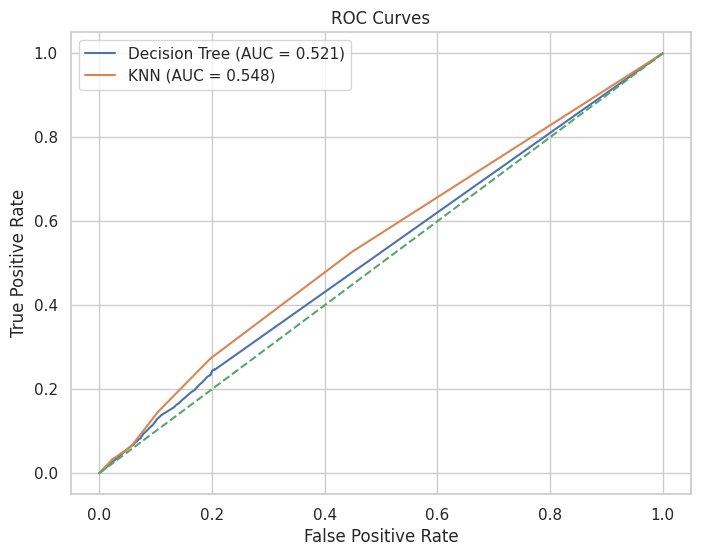

In [68]:
# ============================================================
# 67. ROC CURVES
# ============================================================

fpr_dtree, tpr_dtree, _ = roc_curve(
    y_test,
    dtree_prob
)

fpr_knn, tpr_knn, _ = roc_curve(
    y_test,
    knn_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_dtree,
    tpr_dtree,
    label=f'Decision Tree (AUC = {roc_auc_dtree:.3f})'
)

plt.plot(
    fpr_knn,
    tpr_knn,
    label=f'KNN (AUC = {roc_auc_knn:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()

plt.show()

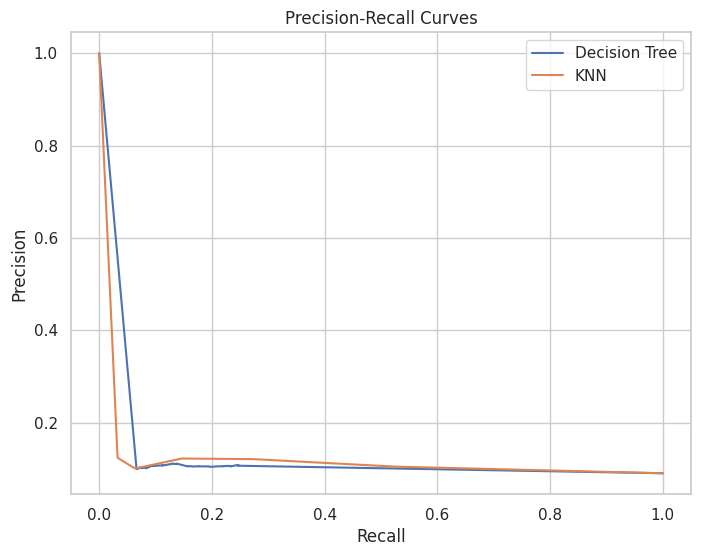

In [69]:
# ============================================================
# 68. PRECISION-RECALL CURVES
# ============================================================

precision_dt, recall_dt, _ = precision_recall_curve(
    y_test,
    dtree_prob
)

precision_knn_curve, recall_knn_curve, _ = precision_recall_curve(
    y_test,
    knn_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_dt,
    precision_dt,
    label='Decision Tree'
)

plt.plot(
    recall_knn_curve,
    precision_knn_curve,
    label='KNN'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()

plt.show()

In [70]:
# ============================================================
# 69. STORE MODEL RESULTS
# ============================================================

model_results = pd.DataFrame({

    'Model': [
        'Decision Tree',
        'KNN'
    ],

    'Accuracy': [
        accuracy_dtree,
        accuracy_knn
    ],

    'Precision': [
        precision_dtree,
        precision_knn
    ],

    'Recall': [
        recall_dtree,
        recall_knn
    ],

    'F1 Score': [
        f1_dtree,
        f1_knn
    ],

    'ROC-AUC': [
        roc_auc_dtree,
        roc_auc_knn
    ]
})

display(
    model_results.style.format({
        'Accuracy': '{:.4f}',
        'Precision': '{:.4f}',
        'Recall': '{:.4f}',
        'F1 Score': '{:.4f}',
        'ROC-AUC': '{:.4f}'
    })
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,0.8212,0.1111,0.1387,0.1234,0.5205
1,KNN,0.8273,0.1226,0.1468,0.1336,0.5481


In [71]:
# ============================================================
# 70. FINAL MODEL COMPARISON
# ============================================================

print("=" * 70)
print("FINAL MODEL PERFORMANCE")
print("=" * 70)

for _, row in model_results.iterrows():

    print(f"\n{row['Model']}")
    print("-" * 30)

    print(f"Accuracy : {row['Accuracy']:.4f}")
    print(f"Precision: {row['Precision']:.4f}")
    print(f"Recall   : {row['Recall']:.4f}")
    print(f"F1 Score : {row['F1 Score']:.4f}")
    print(f"ROC-AUC  : {row['ROC-AUC']:.4f}")

print("\nBest KNN Parameters:")
print(grid_search.best_params_)

FINAL MODEL PERFORMANCE

Decision Tree
------------------------------
Accuracy : 0.8212
Precision: 0.1111
Recall   : 0.1387
F1 Score : 0.1234
ROC-AUC  : 0.5205

KNN
------------------------------
Accuracy : 0.8273
Precision: 0.1226
Recall   : 0.1468
F1 Score : 0.1336
ROC-AUC  : 0.5481

Best KNN Parameters:
{'knn__n_neighbors': 5, 'knn__p': 2, 'knn__weights': 'uniform'}


In [72]:
# ============================================================
# 71. SAVE RESULTS
# ============================================================

model_results.to_csv(
    'model_results.csv',
    index=False
)

top_features.to_csv(
    'decision_tree_feature_importance.csv',
    index=False
)

print("Results saved successfully.")

Results saved successfully.


In [73]:
# ============================================================
# 72. FINAL PROJECT SUMMARY
# ============================================================

print("=" * 70)
print("DIABETES READMISSION PREDICTION - PROJECT SUMMARY")
print("=" * 70)

print(f"\nFinal dataset size: {df.shape[0]:,} patients")
print(f"Number of model features: {X.shape[1]}")

print("\nTarget distribution:")
print(y.value_counts())

print("\nDecision Tree:")
print(f"Accuracy : {accuracy_dtree:.4f}")
print(f"Precision: {precision_dtree:.4f}")
print(f"Recall   : {recall_dtree:.4f}")
print(f"F1 Score : {f1_dtree:.4f}")
print(f"ROC-AUC  : {roc_auc_dtree:.4f}")

print("\nKNN:")
print(f"Accuracy : {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall   : {recall_knn:.4f}")
print(f"F1 Score : {f1_knn:.4f}")
print(f"ROC-AUC  : {roc_auc_knn:.4f}")

print("\nBest KNN Parameters:")
print(grid_search.best_params_)

print("\nTop 10 Decision Tree Features:")
display(top_features)

DIABETES READMISSION PREDICTION - PROJECT SUMMARY

Final dataset size: 67,580 patients
Number of model features: 71

Target distribution:
readmitted
0    61451
1     6129
Name: count, dtype: int64

Decision Tree:
Accuracy : 0.8212
Precision: 0.1111
Recall   : 0.1387
F1 Score : 0.1234
ROC-AUC  : 0.5205

KNN:
Accuracy : 0.8273
Precision: 0.1226
Recall   : 0.1468
F1 Score : 0.1336
ROC-AUC  : 0.5481

Best KNN Parameters:
{'knn__n_neighbors': 5, 'knn__p': 2, 'knn__weights': 'uniform'}

Top 10 Decision Tree Features:


,Feature,Importance
30,number_inpatient_log1p,0.204426
24,change,0.081522
34,num_medications|num_lab_procedures,0.038743
44,gender_1,0.032886
33,time_in_hospital|num_lab_procedures,0.031417
37,change|num_medications,0.028935
2,num_lab_procedures,0.028816
36,age|number_diagnoses,0.027995
0,age,0.027420
31,num_medications|time_in_hospital,0.026094
